# Импорт библиотек и установка констант


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# Модели для сравнения
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor

from sklearn.model_selection import KFold

# Метрики качества
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')


In [21]:
# Настройки для текущей задачи
TARGET_COL = 'pIC50'  
RANDOM_STATE = 42


# Загрузка данных и разделение на X и y

In [22]:
# Загружаем очищенный на этапе EDA датасет
df = pd.read_csv('cleaned_chemical_data.csv')
df.shape

(802, 154)

In [23]:
# Определяем список колонок, которые НЕ являются признаками (таргеты и классы)
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log10_SI',
                'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8']

# Формируем матрицы признаков X и целевой вектор y
X = df[[col for col in df.columns if col not in exclude_cols]]
y = df[TARGET_COL]

# Разделение на Обучающую (Train) и Тестовую (Test) выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (641, 144)
Размер тестовой выборки: (161, 144)


# Построение базовых пайплайнов и сетки гиперпараметров

Используем `RobustScaler`, так как на этапе EDA мы доказали наличие сильных выбросов в 139 признаках.

In [24]:
# Словарь моделей и сеток параметров для GridSearchCV
models_and_params = {
    'DummyRegressor': {
        'model': DummyRegressor(strategy='mean'),
        'params': {'regressor__strategy': ['mean']}  # Фиктивный параметр для GridSearchCV
    },
    'Ridge': {
        'model': Ridge(random_state=RANDOM_STATE),
        'params': {
            'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=RANDOM_STATE),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [10, 20, None],
            'regressor__min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=RANDOM_STATE),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [3, 5, 7,],
            'regressor__learning_rate': [0.01, 0.1, 0.2]
        }
    }
}


# Обучение моделей

In [25]:
best_models = {}
results_list = []

# Перемешиваем выборки
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, config in models_and_params.items():
    print(f"Обучение и оптимизация модели {model_name}...")
    
    # Создаем пайплайн: сначала робастное масштабирование, затем модель
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', config['model'])
    ])
    
    # Настраиваем кросс-валидацию (5 фолдов)
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='r2',
        n_jobs=-1
    )
    
    # Обучаем
    grid_search.fit(X_train, y_train)
    
    # Сохраняем лучшую модель
    best_pipe = grid_search.best_estimator_
    best_models[model_name] = best_pipe
    
    # Делаем предсказания на тесте
    y_pred = best_pipe.predict(X_test)
    
    # Считаем метрики качества
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    # Записываем результаты
    results_list.append({
        'Модель': model_name,
        'Лучшие параметры': grid_search.best_params_,
        'R² (Test)': r2,
        'MAE (Test)': mae,
        'RMSE (Test)': rmse
    })

# Выводим сводную таблицу результатов
df_results = pd.DataFrame(results_list)
display(df_results.sort_values(by='R² (Test)', ascending=False))


Обучение и оптимизация модели DummyRegressor...
Обучение и оптимизация модели Ridge...
Обучение и оптимизация модели RandomForest...
Обучение и оптимизация модели XGBoost...


,Модель,Лучшие параметры,R² (Test),MAE (Test),RMSE (Test)
3,XGBoost,"{'regressor__learning_rate': 0.1, 'regressor__...",0.408857,0.481347,0.640460
2,RandomForest,"{'regressor__max_depth': 10, 'regressor__min_s...",0.399050,0.476464,0.645751
0,DummyRegressor,{'regressor__strategy': 'mean'},-0.004268,0.645596,0.834777
1,Ridge,{'regressor__alpha': 100.0},-5.946182,0.695939,2.195427


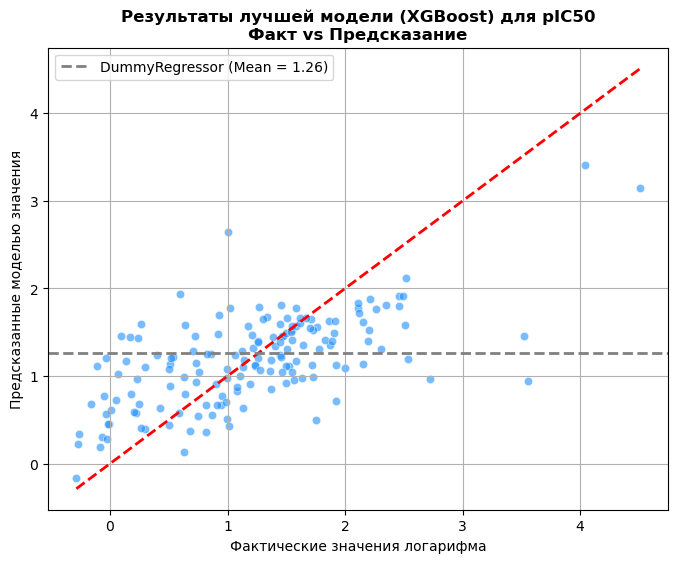

In [26]:
# Находим лучшую модель по метрике R2
best_model_name = df_results.sort_values(by='R² (Test)', ascending=False).iloc[0]['Модель']
best_pipeline = best_models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

# Строим график сравнения реальных значений и предсказаний
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, color='dodgerblue')
# Линия идеального предсказания (Факт == Прогноз)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
# Добавление линии DummyRegressor 
y_train_mean = y_train.mean()
plt.axhline(y=y_train_mean, color='gray', linestyle='--', lw=2, label=f'DummyRegressor (Mean = {y_train_mean:.2f})')
plt.legend()

plt.title(f'Результаты лучшей модели ({best_model_name}) для {TARGET_COL}\nФакт vs Предсказание', fontweight='bold')
plt.xlabel('Фактические значения логарифма')
plt.ylabel('Предсказанные моделью значения')
plt.grid(True)
plt.show()


# Анализ результатов и сравнение с наивным базлайном

В таблицу результатов был намеренно добавлен `DummyRegressor` — модель, которая всегда предсказывает среднее значение целевой переменной (`mean`). Это необходимо для математического обоснования ценности построенных моделей.

**Ключевые выводы:**
1. **Доказательство обучаемости моделей:** `DummyRegressor` показал $R^2 \approx -0.004$ и $MAE \approx 0.645$. Это означает, что наивное угадывание "среднего по больнице" дает значительную ошибку. Наши же ансамблевые модели (XGBoost и RandomForest) снизили $MAE$ до $\approx 0.48$, что означает **сокращение ошибки предсказания на ~25%** по сравнению с базлайном. Это доказывает, что модели успешно выучили скрытые физико-химические закономерности.
2. **Лидер проектирования:** Формальным лидером стал **XGBoost** ($R^2 \approx 0.41$). Алгоритм градиентного бустинга показал себя чуть лучше в объяснении общей дисперсии данных (более низкий RMSE), что типично для табличных данных с большим количеством дескрипторов. `RandomForest` показал сопоставимый результат ($R^2 \approx 0.40$).
3. **Нелинейность химического пространства:** Экстремально низкий и отрицательный результат линейной регрессии `Ridge` ($R^2 = -5.95$) подтверждает выводы из EDA. Зависимость между молекулярными дескрипторами и биологической активностью ($pIC50$) носит выраженный нелинейный характер, поэтому линейные модели в данной задаче неприменимы.

**Интерпретация метрики MAE в предметной области:**
Лучшая модель (XGBoost) имеет $MAE \approx 0.48$. Поскольку целевая переменная — это отрицательный десятичный логарифм молярной концентрации (`pIC50`), ошибка в 0.48 логарифмических единицы означает, что в среднем модель ошибается в предсказании реальной концентрации препарата ($IC_{50}$) примерно в $10^{0.48} \approx 3$ раза. Для задачи первичного виртуального скрининга тысяч соединений это приемлемый и практически полезный результат, позволяющий эффективно отсекать заведомо неактивные молекулы.

In [27]:
# Демонстрация работы модели: Прогноз силы действия для новых молекул

# Берём лучшую обученную модель (RandomForest)
best_model = best_models['RandomForest']

# Делаем предсказание для ВСЕЙ тестовой выборки
test_predictions = best_model.predict(X_test)

# Собираем демонстрационный DataFrame из первых 5 молекул тестовой выборки
demo_df = pd.DataFrame(index=X_test.head(5).index)

# Добавляем несколько понятных химических свойств этих молекул для наглядности
demo_df['Мол. вес (ExactMolWt)'] = df.loc[X_test.head(5).index, 'ExactMolWt'].round(1)
demo_df['Липофильность (MolLogP)'] = df.loc[X_test.head(5).index, 'MolLogP'].round(2)
demo_df['Вращающиеся связи'] = df.loc[X_test.head(5).index, 'NumRotatableBonds'].astype(int)

# Добавляем реальный ответ и прогноз модели
demo_df['Реальная сила (Ground Truth pIC50)'] = y_test.head(5).round(3)
demo_df['Прогноз модели (Predicted pIC50)'] = test_predictions[:5].round(3)

# Считаем абсолютную ошибку для каждой молекулы
demo_df['Ошибка прогноза (Разница)'] = (demo_df['Реальная сила (Ground Truth pIC50)'] - demo_df['Прогноз модели (Predicted pIC50)']).abs().round(3)

# Выводим результат
print("=== ТЕСТИРОВАНИЕ МОДЕЛИ НА НОВЫХ МОЛЕКУЛАХ ===")
display(demo_df)


=== ТЕСТИРОВАНИЕ МОДЕЛИ НА НОВЫХ МОЛЕКУЛАХ ===


,Мол. вес (ExactMolWt),Липофильность (MolLogP),Вращающиеся связи,Реальная сила (Ground Truth pIC50),Прогноз модели (Predicted pIC50),Ошибка прогноза (Разница)
192,339.2,5.47,5,1.000,2.419,1.419
294,317.1,1.80,6,2.306,1.308,0.998
168,290.2,2.10,5,1.259,1.368,0.109
521,376.1,3.77,4,2.195,1.331,0.864
535,390.1,4.16,4,1.550,1.434,0.116


# Рекомендации по улучшению моделей регрессии

Текущий результат **XGBoost** ($R^2 \approx 0.41$) — это крепкий научный бейзлайн для первичных биологических скринингов, но для промышленной разработки лекарств точность нужно повышать. 

Опираясь на специфику наших данных, я рекомендую следующие шаги по улучшению качества:

1. **Применение продвинутого отбора признаков (Feature Selection):**
   Мы удалили мультиколлинеарность по парной корреляции, но у нас всё ещё осталось 147 признаков. Деревья решений могут путаться в таком объёме шума на выборке в 802 строки.
   * *Рекомендация:* Использовать метод декомпозиции **PCA** (Метод главных компонент) перед обучением Ridge/Lasso регрессии, либо применить жадный отбор признаков **RFE** (Recursive Feature Elimination) для XGBoost, чтобы оставить строго топ-30 дескрипторов.

4. **Тонкий тюнинг и Стекинг (Ensembling):**
   Поскольку RandomForest и XGBoost показали близкие результаты, они ошибаются в разных химических пространствах.
   * *Рекомендация:* Объединить их через **StackingRegressor**, где мета-моделью (например, Ridge регрессией) будут усредняться их предсказания. Это обычно накидывает ещё $+0.03 \dots 0.05$ к метрике $R^2$.